In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from Bio.Seq import Seq
from Bio.Data import CodonTable

In [3]:
from Bio import SeqIO

In [4]:
import subprocess
import glob
import os
import sys

from IPython.display import display, clear_output

In [5]:
import sys
sys.path.append('/data/mhoffert/fiererlab/adenylate_kinase_ogt/protein_utils/')
from protein_utils import read_pfam_table_pandas, pfam_table_columns

In [6]:
import gzip

## Notes
Uses "targeted_assembly" environment

## Functions

In [7]:
def six_frame_translation(dna_sequence):
    """
    Performs six-frame translation of a DNA sequence.

    Args:
        dna_sequence (str): The DNA sequence to translate.

    Returns:
        dict: A dictionary containing the translated amino acid sequences
              for all six frames. Keys are frame names (e.g., 'Forward_Frame_1'),
              values are Seq objects of the translated protein.
    """
    seq_obj = Seq(dna_sequence)
    translations = {}

    standard_table = CodonTable.ambiguous_dna_by_id[1] 

    # Forward frames
    for i in range(3):
        frame_name = f"fwd_{i+1}"
        translated_seq = seq_obj[i:].translate(table=standard_table, to_stop=False)
        translations[frame_name] = translated_seq

    # Reverse complement frames
    reverse_complement_seq_obj = seq_obj.reverse_complement()
    for i in range(3):
        frame_name = f"rev_{i+1}"
        translated_seq = reverse_complement_seq_obj[i:].translate(table=standard_table, to_stop=False)
        translations[frame_name] = translated_seq

    return translations

def simple_hamming_distance(s1: str, s2: str) -> int:
    """Calculates the Hamming distance for two strings of equal length."""
    return sum(c1 != c2 for c1, c2 in zip(s1, s2))

def check_fuzzy_match(query: str, target: str, max_offset: int = 2) -> bool:
    """
    Checks if the query and target match perfectly, allowing for up to
    max_offset (e.g., 2) characters of difference in their start/end points.
    """
    
    L_Q = len(query)
    L_T = len(target)
    

    for relative_shift in range(-2 * max_offset, 2 * max_offset + 1):
        
        q_start = max(0, relative_shift)
        t_start = max(0, -relative_shift)

        overlap_length = min(L_Q - q_start, L_T - t_start)

        if overlap_length <= 0:
            continue

        q_sub = query[q_start : q_start + overlap_length]
        t_sub = target[t_start : t_start + overlap_length]

        distance = simple_hamming_distance(q_sub, t_sub)

        if distance == 0:
            return True 

    return False 

## Build some test datasets

In [3]:
gtdb_md = pd.read_csv('./../data/targeted_assembly/bac120_metadata.tsv.gz', 
            sep='\t',
            compression='gzip')

In [8]:
gtdb_md[gtdb_md.gtdb_representative.eq('t')].gtdb_taxonomy.str.contains('s__Udaeobacter sp038214915').sum()

np.int64(1)

In [17]:
%%time
for env in ['soil', 'gut', 'plant', 'aquatic']:

    with open(f'./../data/targeted_assembly/common_{env}_taxa.txt', 'r') as handle:
        taxa = [l.strip().split('; ')[-1] for l in handle.readlines()]
        
    taxa_md = pd.concat([gtdb_md[gtdb_md.gtdb_representative.eq('t') & gtdb_md.gtdb_taxonomy.str.contains(t)] for t in taxa])
    
    with open(f'./../data/targeted_assembly/{env}_accs.txt', 'w') as handle:
        handle.write('\n'.join(list(taxa_md['accession'].unique())))

CPU times: user 1min 56s, sys: 104 ms, total: 1min 56s
Wall time: 1min 56s


## Step 1: annotate ADKs in genomes

In [20]:
for sim in range(5):
    genomes = glob.glob(f'./../data/targeted_assembly/aquatic_sims/simulate_1e7/sim{sim}/genomes/sylph_db/*.fna')
    # genomes = glob.glob('./../data/targeted_assembly/gut_sims/simulations/sim_1e6/sim0_spades/scaffolds.fna')
    genomes = [os.path.abspath(g) for g in genomes]
    print(f'{len(genomes)} genomes found')

    for i, g in enumerate(genomes):
    
        display(f'{i} of {len(genomes)}')
        clear_output(wait=True)
    
        base = g.replace('.fna', '')
        command = f'prodigal -p single -i {base}.fna -a {base}.faa -o {base}.gbk'
    
        # Run the command
        process = subprocess.Popen(
            command,
            shell=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True
        )
    
        stdout, stderr = process.communicate()
        
        # Check for non-zero exit code
        if process.returncode != 0:
            print(f"Command failed with exit code {process.returncode}, {stdout.strip()}")
            break
        

'49 of 50'

## Step 2: Annotate original ADK in the genomes

In [21]:
HMM_MODEL = os.path.abspath('./../data/PF00406.hmm')

for sim in range(5):
    genomes = glob.glob(f'./../data/targeted_assembly/aquatic_sims/simulate_1e7/sim{sim}/genomes/sylph_db/*.fna')
    # genomes = glob.glob('./../data/targeted_assembly/gut_sims/simulations/sim_1e6/sim0_spades/scaffolds.fna')
    genomes = [os.path.abspath(g) for g in genomes]
    print(f'{len(genomes)} genomes found')

    for i, g in enumerate(genomes):
    
        display(f'{i} of {len(genomes)}')
        clear_output(wait=True)
        
        base = g.replace('.fna', '')
        command = f'hmmsearch --tblout {base}_hmmsearch.tbl {HMM_MODEL} {base}.faa > {base}_hmmsearch.log'
    
        # Run the command
        process = subprocess.Popen(
            command,
            shell=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True
        )
    
        stdout, stderr = process.communicate()
        
        # Check for non-zero exit code
        if process.returncode != 0:
            print(f"Command failed with exit code {process.returncode}, {stderr.strip()}")
            break

'49 of 50'

## Step 3: Get the reads overlapping the original ADK

### Step 3a: get all hmm matching ORFs

In [59]:
# parse the hmm hits to find ORFs of interest
per_genome_hmm_hits = [] 

for sim in range(5):
    hmm_tables = glob.glob(f'./../data/targeted_assembly/aquatic_sims/simulate_1e7/sim{sim}/genomes/sylph_db/*.tbl')
    # hmm_tables = glob.glob('./../data/targeted_assembly/gut_sims/simulations/sim_1e7/genomes/sylph_db/*.tbl')
    hmm_tables = [os.path.abspath(h) for h in hmm_tables]

    for hmm_table in hmm_tables:
        
        genome = os.path.basename(hmm_table).replace('_hmmsearch.tbl', '')
        try:
            # read hmm hit table
            table = read_pfam_table_pandas(hmm_table)
            # for each hit
            for index, row in table.iterrows():
                # save info
                per_genome_hmm_hits.append(pd.Series(index=['genome', 'orf_id', 'score', 'sim'], 
                         data=[genome, row['target_name'], row['full_score'], sim]))
        except ValueError:
            print(f'Table failed to read: {genome}')
        
per_genome_hmm_hits = pd.concat(per_genome_hmm_hits, axis=1).T

In [60]:
per_genome_hmm_hits

,genome,orf_id,score,sim
0,GB_GCA_003209915.1_genomic,QCOF01000002.1_30,169.5,0
1,GB_GCA_003209915.1_genomic,QCOF01000003.1_31,16.2,0
2,GB_GCA_028226535.1_genomic,JAOJEG010000029.1_7,84.6,0
3,GB_GCA_028226535.1_genomic,JAOJEG010000002.1_33,13.3,0
4,GB_GCA_028226535.1_genomic,JAOJEG010000007.1_13,12.5,0
...,...,...,...,...
519,RS_GCF_014697575.1_genomic,JACJSC010000004.1_18,13.7,4
520,RS_GCF_014697575.1_genomic,JACJSC010000001.1_321,12.9,4
521,RS_GCF_014697575.1_genomic,JACJSC010000002.1_77,12.5,4
522,RS_GCF_014697575.1_genomic,JACJSC010000029.1_61,11.8,4


In [61]:
# with open('./../data/targeted_assembly/gut_sims/simulations/sim_1e6/sim0_spades/scaffolds.faa', 'r') as handle:
#     records = [r for r in SeqIO.parse(handle, format='fasta')]


### Step 3b: get the ORFs seqs and verify the coordinates in the OG genome

need to edit this to work for all sims

In [62]:
# get the location of the orfs
partial_base = os.path.abspath('./../data/targeted_assembly/aquatic_sims/simulate_1e7/')
per_genome_hmm_hits['check_orf'] = False

for index, row in per_genome_hmm_hits.iterrows():
    sim = row['sim']
    base = os.path.join(partial_base, f'sim{sim}/genomes/sylph_db/')
    display(index)
    clear_output(wait=True)
    with open(os.path.join(base, row['genome'] + '.faa'), 'r') as handle:
        faa_records = [r for r in SeqIO.parse(handle, format='fasta')]
    orf_record = [r for r in faa_records if f"{row['orf_id']}" == r.name]
    
    # check we've found it
    assert len(orf_record) == 1, f'len orf records should be 1: {len(orf_record)}'
    # get fasta header for this orf
    splits = orf_record[0].description.split(' # ')
    start, stop, strand = int(splits[1]), int(splits[2]), int(splits[3])
    per_genome_hmm_hits.loc[index, 'start'] = start
    per_genome_hmm_hits.loc[index, 'stop'] = stop
    per_genome_hmm_hits.loc[index, 'strand'] = strand
    per_genome_hmm_hits.loc[index, 'orf_aa'] = str(orf_record[0].seq)

    # validate we've found the orf by matching to translation from contig
    with open(os.path.join(base, row['genome'] + '.fna'), 'r') as handle:
        genome_records =[r for r in SeqIO.parse(handle, format='fasta')]

    # get orf
    orf_contig = [r for r in genome_records if r.name == '_'.join(row['orf_id'].split('_')[:-1])]
    
    assert len(orf_contig) == 1, 'Contigs matching orf should be only 1'
    per_genome_hmm_hits.loc[index, 'contig'] = '_'.join(row['orf_id'].split('_')[:-1])

    # get DNA sequence
    dna_seq = orf_contig[0].seq[start:stop]

    per_genome_hmm_hits.loc[index, 'orf_dna'] = '_'.join(row['orf_id'].split('_')[:-1])

    # translate
    for key, item in six_frame_translation(dna_seq).items():
        if check_fuzzy_match(orf_record[0].seq[1:-1], item[1:-1]):
            per_genome_hmm_hits.loc[index, 'check_orf'] = True
            per_genome_hmm_hits.loc[index, 'orf_dna'] = str(orf_record[0].seq)
               

/data/mhoffert/miniforge3/envs/targeted_assembly/lib/python3.14/site-packages/Bio/Seq.py:2877: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


In [63]:
per_genome_hmm_hits.head()

,genome,orf_id,score,sim,check_orf,start,stop,strand,orf_aa,contig,orf_dna
0,GB_GCA_003209915.1_genomic,QCOF01000002.1_30,169.5,0,True,28238.0,28801.0,-1.0,MNIILFGPPGAGKGTQAKYLVKKLNNFQISTGDILREEIKNNSDIG...,QCOF01000002.1,MNIILFGPPGAGKGTQAKYLVKKLNNFQISTGDILREEIKNNSDIG...
1,GB_GCA_003209915.1_genomic,QCOF01000003.1_31,16.2,0,True,33687.0,34343.0,1.0,MFKRKNIIKIAIDSPAAAGAGTQAKLISKHYNLLQLETGLIYRYIA...,QCOF01000003.1,MFKRKNIIKIAIDSPAAAGAGTQAKLISKHYNLLQLETGLIYRYIA...
2,GB_GCA_028226535.1_genomic,JAOJEG010000029.1_7,84.6,0,True,4268.0,4498.0,-1.0,MNIILFGPPGAGKGTQAQLIVKKHNYFQLSTGDLLRSETKKNTDLG...,JAOJEG010000029.1,MNIILFGPPGAGKGTQAQLIVKKHNYFQLSTGDLLRSETKKNTDLG...
3,GB_GCA_028226535.1_genomic,JAOJEG010000002.1_33,13.3,0,True,35077.0,35733.0,1.0,MIKRKNIIKIAIDSPAAAGAGTLAKVISKHYNLFYLDTGKIYRMIA...,JAOJEG010000002.1,MIKRKNIIKIAIDSPAAAGAGTLAKVISKHYNLFYLDTGKIYRMIA...
4,GB_GCA_028226535.1_genomic,JAOJEG010000007.1_13,12.5,0,True,9662.0,10069.0,1.0,MKIILIMGLPGSGKTTLANELAPILNAKRLNADEVRKEANDWDFSE...,JAOJEG010000007.1,MKIILIMGLPGSGKTTLANELAPILNAKRLNADEVRKEANDWDFSE...


In [65]:
# check to make sure we successfully found every ORF
print(per_genome_hmm_hits['check_orf'].unique())

[ True]


### Step 3c: get the reads overlapping each ORF

In [66]:
partial_base = os.path.abspath('./../data/targeted_assembly/aquatic_sims/simulate_1e7/')
paired_patterns = ['R1', 'R2']
# parameter to control how far from start and stop of gene filtered reads start
BUFFER = 400

for sim in range(5):
    print(f'Working on sim: {sim} with buffer {BUFFER}')
    # get the location of the orfs
    sim_base = os.path.join(partial_base, f'sim{sim}')
    genome_base = os.path.join(f'{sim_base}', 'genomes/sylph_db/')
    read_base = os.path.join(f'{sim_base}', 'fqs')

    # for making histogram of start locs
    overlapping_read_locs = {}

    os.makedirs(os.path.join(f'{sim_base}', 'filtered'), exist_ok=True)

    # clean up files
    cat_filtered_r1 = os.path.join(f'{sim_base}', f'filtered/sim{sim}_filtered_b{BUFFER}_{paired_patterns[0]}.fq.gz')
    cat_filtered_r2 = os.path.join(f'{sim_base}', f'filtered/sim{sim}_filtered_b{BUFFER}_{paired_patterns[1]}.fq.gz')
    
    # delete concatenated files
    if os.path.exists(cat_filtered_r2):
        print('Files found. removing for rewrite...')
    
        os.remove(cat_filtered_r1)
        os.remove(cat_filtered_r2)
        
        assert not os.path.exists(cat_filtered_r1), f'File still exists: {cat_filtered_r1}'
    else:
        print('No cat files found')
    
    check_ind_files = glob.glob(os.path.join(read_base, f'*_filtered_b{BUFFER}_{paired_patterns[0]}.fq.gz'))
    
    if len(check_ind_files) > 0:
        print('Ind files found. Removing for rewrite...')
        # delete individual files
        for pattern in paired_patterns:
            ind_filtered = glob.glob(os.path.join(read_base, f'*_filtered_b{BUFFER}_{pattern}.fq.gz'))
            for file in ind_filtered:
                os.remove(file)
    
            check_ind_files = glob.glob(os.path.join(read_base, f'*_filtered_b{BUFFER}_{pattern}.fq.gz'))
            
            assert len(check_ind_files) == 0, f'Not all files deleted: {"\n".join(check_ind_files)}'
    else:
        print('No individual files found')
    
    ## Parse the reads to find reads generated from reads of interest
    # ------------------------------------------------------------------
    print()
    for index, row in per_genome_hmm_hits[per_genome_hmm_hits['sim'].eq(sim)].iterrows():
        
        print(index, end='\r')
        # clear_output(wait=True)
        
        with open(os.path.join(genome_base, row['genome'] + '.fna'), 'r') as handle:
            genome_records =[r for r in SeqIO.parse(handle, format='fasta')]
    
        contig_record = [r for r in genome_records if r.name == row['contig']]
        assert len(contig_record) == 1
        contig_len = len(contig_record[0].seq)
    
        # get the reads
        overlapping_reads = []
        read_count = 0
        
        per_genome_hmm_hits.loc[index, f'n_reads_{BUFFER}'] = 0
        overlapping_read_locs[row['orf_id']] = {}
        
        for pattern in ['R1', 'R2']:
            with gzip.open(os.path.join(read_base, f'{row["genome"].replace("_genomic", '')}_{pattern}.aln.gz'), 'rb') as handle:
                lines = [l.decode().strip() for l in handle.readlines()]
                
            # iterate through reads and look for overlapping ones
            for i, l in enumerate(lines):
                if l[0] == '>':
                    read_count += 1
                    read_contig, read_id, read_start, read_strand = l.split('\t')
                    # if the contig matches
                    # to save time
                    if read_contig[1:] == contig_record[0].name:
                        read_start = int(read_start)
                        read_seq = lines[i+1]
                        read_end = read_start + len(read_seq)
    
                        # if it's a negative strand read, transform its coords to positive
                        if read_strand == '-':
                            read_end = contig_len - read_start
                            read_start = contig_len - (read_start + len(read_seq))
        
                        # print('Contig len', contig_len, 'Read start', read_start, 'Read stop', read_end, 'ORF start', row['start'], row['stop'])
                        gene_end = row['stop'] + BUFFER
                        gene_start = row['start'] - BUFFER
                        if (gene_start <= read_start <= gene_end) or (gene_start <= read_end <= gene_end):
                            overlapping_reads.append(read_id)
                            per_genome_hmm_hits.loc[index, f'n_reads_{BUFFER}'] += 1
                            overlapping_read_locs[row['orf_id']][read_id] = (read_start - row['start']) / (row['stop'] - row['start'])
    
        # if some reads were found simulated from the gene, 
        # write a file containing those reads
        if len(overlapping_reads) > 0:
            unique_read_ids = list(set([s.split('/')[0] for s in overlapping_reads]))
            filter_reads = [f'{s}/{i}' for s in unique_read_ids for i in [1,2]]
            reads_found = 0
            
            for pattern in paired_patterns:
    
                infile_path = os.path.join(read_base, f'{row["genome"].replace("_genomic", '')}_{pattern}.fq.gz')
                outfile_path = os.path.join(read_base, f'{row["genome"].replace("_genomic", '')}_filtered_b{BUFFER}_{pattern}.fq.gz')
                
                with gzip.open(infile_path, 'rt') as infile, \
                     gzip.open(outfile_path, 'at') as outfile:
                            
                    for record in SeqIO.parse(infile, "fastq"):
                        
                        # record.id contains the read ID (usually before the first space)
                        read_id = record.id
                        
                        # 4. Check if the read ID is in the target set
                        if read_id in filter_reads:
                            
                            # 5. Use SeqIO.write() to output the record
                            SeqIO.write(record, outfile, "fastq")
                            reads_found += 1
            
            assert reads_found == len(filter_reads), f"Didn't find all the reads; {reads_found} found, {len(filter_reads)} searched"
    
    for pattern, cat_file in zip(paired_patterns, [cat_filtered_r1, cat_filtered_r2]):
        ind_pattern = os.path.join(read_base, f'*_filtered_b{BUFFER}_{pattern}.fq.gz')
        command = f'cat {ind_pattern} > {cat_file}'
        
        # write concat files
        # Run the command
        process = subprocess.Popen(
            command,
            shell=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True
        )
        
        stdout, stderr = process.communicate()
        
        # Check for non-zero exit code
        if process.returncode != 0:
            print(f"Command failed with exit code {process.returncode}, {stderr.strip()}")
            break
        else:
            print(f'Wrote {cat_file}')

    print('')
    print('-'*60)

Working on sim: 0 with buffer 400
No cat files found
No individual files found

Wrote /data/mhoffert/fiererlab/adenylate_kinase_ogt/data/targeted_assembly/aquatic_sims/simulate_1e7/sim0/filtered/sim0_filtered_b400_R1.fq.gz
Wrote /data/mhoffert/fiererlab/adenylate_kinase_ogt/data/targeted_assembly/aquatic_sims/simulate_1e7/sim0/filtered/sim0_filtered_b400_R2.fq.gz

------------------------------------------------------------
Working on sim: 1 with buffer 400
No cat files found
No individual files found

Wrote /data/mhoffert/fiererlab/adenylate_kinase_ogt/data/targeted_assembly/aquatic_sims/simulate_1e7/sim1/filtered/sim1_filtered_b400_R1.fq.gz
Wrote /data/mhoffert/fiererlab/adenylate_kinase_ogt/data/targeted_assembly/aquatic_sims/simulate_1e7/sim1/filtered/sim1_filtered_b400_R2.fq.gz

------------------------------------------------------------
Working on sim: 2 with buffer 400
No cat files found
No individual files found

Wrote /data/mhoffert/fiererlab/adenylate_kinase_ogt/data/targete

### Notes

In [56]:
partial_base

'/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/targeted_assembly/aquatic_sims/simulate_1e5'

In [57]:
# save per genome hits file
per_genome_hmm_hits.to_csv(f'{partial_base}/per_genome_hmm_hits.tsv', sep='\t')

In [58]:
faa_file = []
for index, row in per_genome_hmm_hits.iterrows():
    faa_file.append(f'>{row["orf_id"]}\n')
    faa_file.append(f'{row["orf_aa"].replace("*", "")}\n')

with open(f'{partial_base}/screening_proteins.faa', 'w') as handle:
    handle.write(''.join(faa_file))

In [ ]:
##

## Step 4: The comparison to MMSeqs.
Developed an mmseqs-based workflow. The steps:
```
# create db of proteins and dbs of reads
mmseqs createdb ./../20240122_all_adks.faa proteinDB --threads 16 --dbtype 1
mmseqs createdb ./../aquatic_sims/simulate_1e5/sim0/sim0_R1.fq.gz fwdDB --threads 16 --dbtype 2
mmseqs createdb ./../aquatic_sims/simulate_1e5/sim0/sim0_R2.fq.gz revDB --threads 16 --dbtype 2

# search reads against proteins
mmseqs search fwdDB proteinDB fwd_alnDB ./tmp/ --threads 16 -a TRUE
mmseqs search revDB proteinDB rev_alnDB ./tmp/ --threads 16 -a TRUE

# convert to sam
mmseqs convertalis fwdDB proteinDB fwd_alnDB fwd_alnDB.sam --format-mode 1 --threads 16
mmseqs convertalis revDB proteinDB rev_alnDB rev_alnDB.sam --format-mode 1 --threads 16

# filter down original reads
# from mmseqs_test dir
bash ./../filter_sams.sh fwd_alnDB.sam rev_alnDB.sam ./../aquatic_sims/simulate_1e5/sim0/sim0_R1.fq.gz ./../aquatic_sims/simulate_1e5/sim0/sim0_R2.fq.gz ./aquatic_sim1e5_sim0
```
or just:
`./../map_reads.sh -d ./../aquatic_sims/simulate_1e5/sim0/screening_proteins.faa -p "./../aquatic_sims/simulate_1e5/sim*/sim*_R1.fq.gz" -o ./aquatic_1e5`
then:
`./../filter_sams.sh aquatic_1e5_sim0_fwd.sam aquatic_1e5_sim0_rev.sam ./../aquatic_sims/simulate_1e5/sim0/sim0_R1.fq.gz ./../aquatic_sims/simulate_1e5/sim0/sim0_R2.fq.gz ./aquatic_sim1e5_sim0`

In [69]:
# print out list of commands for filtering
cov = '1e7'

for sim in range(5):
    fwd = f'mmseqs_assemblies/aquatic_sims/aquatic_{cov}_adksdb_sim{sim}_fwd.sam'
    rev = f'mmseqs_assemblies/aquatic_sims/aquatic_{cov}_adksdb_sim{sim}_rev.sam'
    fwd_reads = f'aquatic_sims/simulate_{cov}/sim{sim}/sim{sim}_R1.fq.gz'
    rev_reads = f'aquatic_sims/simulate_{cov}/sim{sim}/sim{sim}_R2.fq.gz'
    out = f'mmseqs_assemblies/aquatic_sims/aquatic_{cov}_adksdb_sim{sim}'
    command = f'bash filter_sams.sh {fwd} {rev} {fwd_reads} {rev_reads} {out}'
    print(command)

bash filter_sams.sh mmseqs_assemblies/aquatic_sims/aquatic_1e7_adksdb_sim0_fwd.sam mmseqs_assemblies/aquatic_sims/aquatic_1e7_adksdb_sim0_rev.sam aquatic_sims/simulate_1e7/sim0/sim0_R1.fq.gz aquatic_sims/simulate_1e7/sim0/sim0_R2.fq.gz mmseqs_assemblies/aquatic_sims/aquatic_1e7_adksdb_sim0
bash filter_sams.sh mmseqs_assemblies/aquatic_sims/aquatic_1e7_adksdb_sim1_fwd.sam mmseqs_assemblies/aquatic_sims/aquatic_1e7_adksdb_sim1_rev.sam aquatic_sims/simulate_1e7/sim1/sim1_R1.fq.gz aquatic_sims/simulate_1e7/sim1/sim1_R2.fq.gz mmseqs_assemblies/aquatic_sims/aquatic_1e7_adksdb_sim1
bash filter_sams.sh mmseqs_assemblies/aquatic_sims/aquatic_1e7_adksdb_sim2_fwd.sam mmseqs_assemblies/aquatic_sims/aquatic_1e7_adksdb_sim2_rev.sam aquatic_sims/simulate_1e7/sim2/sim2_R1.fq.gz aquatic_sims/simulate_1e7/sim2/sim2_R2.fq.gz mmseqs_assemblies/aquatic_sims/aquatic_1e7_adksdb_sim2
bash filter_sams.sh mmseqs_assemblies/aquatic_sims/aquatic_1e7_adksdb_sim3_fwd.sam mmseqs_assemblies/aquatic_sims/aquatic_1e7_a

In [36]:
#print out list of commands for assembling
cov = '1e7'
for sim in range(5):
    pattern = f'"mmseqs_assemblies/aquatic_sims/aquatic_{cov}_adksdb_sim{sim}*_R1.fq.gz"'
    command = f'bash assemble_reads.sh -i {pattern} -o mmseqs_assemblies/aquatic_sims/'
    print(command)

bash assemble_reads.sh -i "mmseqs_assemblies/aquatic_sims/aquatic_1e7_adksdb_sim0*_R1.fq.gz" -o mmseqs_assemblies/aquatic_sims/
bash assemble_reads.sh -i "mmseqs_assemblies/aquatic_sims/aquatic_1e7_adksdb_sim1*_R1.fq.gz" -o mmseqs_assemblies/aquatic_sims/
bash assemble_reads.sh -i "mmseqs_assemblies/aquatic_sims/aquatic_1e7_adksdb_sim2*_R1.fq.gz" -o mmseqs_assemblies/aquatic_sims/
bash assemble_reads.sh -i "mmseqs_assemblies/aquatic_sims/aquatic_1e7_adksdb_sim3*_R1.fq.gz" -o mmseqs_assemblies/aquatic_sims/
bash assemble_reads.sh -i "mmseqs_assemblies/aquatic_sims/aquatic_1e7_adksdb_sim4*_R1.fq.gz" -o mmseqs_assemblies/aquatic_sims/


In [ ]:
# print out list of commands for filtering
glob.glob('mmseqs_assemblies/')

### Determine overlap of actual and mapped reads

In [246]:
def get_ids(path):
    """Extracts Read IDs (first word after @) from a gzipped FASTQ."""
    with gzip.open(path, 'rt') as f:
        # IDs are on lines 0, 4, 8... (0-indexed). We strip the leading '@'.
        return {line.split()[0][1:] for i, line in enumerate(f) if i % 4 == 0}
        
# Load Sets
print("Loading IDs...")
f_set = get_ids('./../data/targeted_assembly/mmseqs_test/aquatic_sim1e5_sim0_R1.fq.gz')
t_set = get_ids('./../data/targeted_assembly/aquatic_sims/simulate_1e5/sim0/filtered/sim0_filtered_b400_R1.fq.gz')

# Compare
print(f"--- Comparison Results ---")
print(f"Filtered Count:  {len(f_set)}")
print(f"True Count:      {len(t_set)}")
print(f"Correct (Match): {len(f_set & t_set)}")
print(f"False Positives: {len(f_set - t_set)} (In Filtered but not True)")
print(f"False Negatives: {len(t_set - f_set)} (In True but not Filtered)")

Loading IDs...
--- Comparison Results ---
Filtered Count:  479
True Count:      244
Correct (Match): 97
False Positives: 382 (In Filtered but not True)
False Negatives: 147 (In True but not Filtered)


In [247]:
# get locations of all reads
locs = list(set([overlapping_read_locs[orf][read] for orf in overlapping_read_locs.keys() for read in overlapping_read_locs[orf].keys()]))
read_keys = list(set([read.replace('/1-1', '').replace('/2', '') for orf in overlapping_read_locs.keys() for read in overlapping_read_locs[orf].keys()]))
# get locations of mapped reads
mapped_locs = [overlapping_read_locs[orf][read] for orf in overlapping_read_locs.keys() for read in overlapping_read_locs[orf].keys() if read.replace('/1-1', '/1') in f_set]

In [248]:
fwd_ids = set([read.replace('/1-1', '') for orf in overlapping_read_locs.keys() for read in overlapping_read_locs[orf].keys() if '/1-1' in read])
rev_ids = set([read.replace('/2', '') for orf in overlapping_read_locs.keys() for read in overlapping_read_locs[orf].keys() if '/2' in read])
print('N fwd:', len(fwd_ids), ', N rev:', len(rev_ids))
print(f'fwd & rev: {len(fwd_ids & rev_ids)}')
print(f'fwd only: {len(fwd_ids - rev_ids)}')
print(f'rev only: {len(rev_ids - fwd_ids)}')

print('-'*50)

print(f'N locs: {len(locs)}, which is {len(fwd_ids & rev_ids)} * 2 + {len(fwd_ids - rev_ids)} + {len(rev_ids - fwd_ids)}')

N fwd: 228 , N rev: 221
fwd & rev: 205
fwd only: 23
rev only: 16
--------------------------------------------------
N locs: 447, which is 205 * 2 + 23 + 16


(-2.0, 2.0)

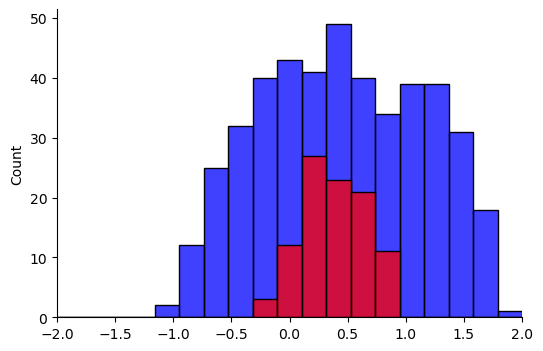

In [250]:
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(locs, fill=True, color='blue', common_norm=False, bins=np.linspace(-2,2, 20))
sns.histplot(mapped_locs, fill=True, color='red', common_norm=False, bins=np.linspace(-2,2, 20))
sns.despine()
ax.set_xlim(-2, 2)

## Step 5: Performing assemblies

Need to write a script to perform assemblies with spades and penguin to start, on each of three sets of fastqs:
1. Full
2. Filtered
3. mapped

More details in commands.md

## Step 6: Assessment of the assemblies

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from random import uniform, choice

### Step 6a: collate assemblies

In [123]:
def get_assembly_params(filename):
    # Strip extension and split by underscore
    tokens = filename.split('/')[-1].rsplit('.', 1)[0].split('_')
    
    # Define lookup sets for fixed categories
    tools = {'spades', 'plass'}
    systems = {'aquatic', 'gut', 'soil', 'plant'}
    coverages = {'1e5', '1e6', '1e7'}
    filtered_types = {'full', 'filtered', 'adksdb'}

    params = {}
    for t in tokens:
        
        if t in tools: params['tool'] = t
        elif t in systems: params['system'] = t
        elif t in coverages: params['coverage'] = float(t)
        elif t in filtered_types: params['filtered'] = t
        elif t.startswith('sim'): params['sim'] = t
        elif t.startswith('b') and t[1:].isdigit(): params['buffer'] = int(t.lstrip('b'))
            
    return params


def parse_assemblies(fp):
    paths = glob.glob(fp)
    series_list = [pd.Series(get_assembly_params(p) | {'file':p}) for p in paths]
    path_data = pd.concat(series_list, axis=1).T
    return path_data

In [146]:
base_path = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/targeted_assembly'

locs = ['filtered', 'mmseqs', 'full']
assembly_info = pd.concat([parse_assemblies(f'{base_path}/{_dir}_assemblies/aquatic_sims/*.faa') for _dir in locs]).reset_index(drop=True)

In [147]:
cov_mapper = {100000:'1e5', 1000000:'1e6', 10000000:'1e7'}
assembly_info['actual'] = assembly_info['coverage'].apply(lambda x: f'{base_path}/aquatic_sims/simulate_{cov_mapper[x]}/screening_proteins.faa')

In [151]:
import subprocess
import tempfile
import shutil
import os
from tqdm import tqdm

In [202]:
def get_actual_seqs(info_fp, sim):
    df = pd.read_csv(info_fp, sep='\t', index_col=0)
    df = df.query(f'sim == {sim}')
    return set(df['orf_id'].values)

In [235]:
def run_mmseqs_search(target_path, assembled_path, min_id=0, min_cov=0):
    """
    Runs MMseqs2 easy-search using a temp file for output and captures logs.
    """
    best_hits = {}
    
    with tempfile.TemporaryDirectory() as tmp_dir:
        # Define a concrete file path for the output
        result_file = os.path.join(tmp_dir, "results.tsv")
        
        cmd = [
            "mmseqs", "easy-search",
            target_path,
            assembled_path,
            result_file,  # Concrete file path instead of 'stdout'
            tmp_dir,
            "--min-seq-id", str(min_id),
            "-c", str(min_cov),
            '--alignment-mode', "4",
            "--cov-mode", "1",
            "--format-output", "query,target,pident,qcov,tcov,qlen,tlen,evalue",
            "-v", "3"
        ]
        
        # Run process; capture stderr for troubleshooting
        process = subprocess.run(cmd, capture_output=True, text=True)
        stderr_logs = process.stderr

        if process.returncode != 0:
            return None, stderr_logs

        # Read and parse the temp file if it exists
        if os.path.exists(result_file):
            with open(result_file, 'r') as f:
                for line in f:
                    cols = line.strip().split('\t')
                    if len(cols) < 5: continue
                    
                    query_id = cols[0]
                    if query_id not in best_hits:
                        best_hits[query_id] = {
                            'target': cols[1],
                            'pident': float(cols[2]),
                            'qcov':   float(cols[3]),
                            'tcov':   float(cols[4]),
                            'qlen':   float(cols[5]),
                            'tlen':   float(cols[6]),
                            'evalue': float(cols[7])
                        }
        
        return best_hits, stderr_logs

In [277]:
def classify_alignments(df):
    """
    Classifies MMseqs2 alignments into fragments, assembled, or misassembled.
    Expects columns: pident, tcov, qlen, tlen
    """
    # 1. Define the conditions
    # Assembled: High identity and nearly identical lengths
    is_assembled = (df['pident'] > 95) & ((df['qlen'] - df['tlen']).abs() <= 2)
    
    # Fragment: Perfect identity but incomplete coverage of the target
    is_fragment = (df['pident'] == 100) & (df['tcov'] < 100)

    # 2. Apply classification with priority to 'assembled'
    conds = [is_assembled, is_fragment]
    choices = ['assembled', 'fragment']
    
    df['class'] = np.select(conds, choices, default='misassembled')
    
    return df

In [332]:
with tqdm(total=assembly_info.shape[0], desc="Checking accuracy") as pbar:
    for index, row in assembly_info.iterrows():
        
        hits, stderr = run_mmseqs_search(row['file'], row['actual'], 0.1, 0.1)
        target_hits = pd.DataFrame(hits).T
    
        actual_seqids = get_actual_seqs(row['actual'].replace('screening_proteins.faa', 'per_genome_hmm_hits.tsv'), 0)
    
        plotdf = target_hits[target_hits['target'].isin(actual_seqids)].copy()
    
        plotdf = classify_alignments(plotdf)
    
        cols = ['pident','qcov','tcov','qlen','tlen', 'evalue']
        # get top hit per type (assembled, etc.)
        class_hits = plotdf.groupby(['target', 'class'])[cols].apply(lambda x: x.sort_values('pident', ascending=False).head(1))
        class_hits_wide = class_hits.droplevel(level=None, axis=0)['pident'].unstack()
        temp = (~class_hits_wide.reindex(list(actual_seqids)).isnull()).sum().rename('blah')
        # add counts of each type as columns in df
        assembly_info.loc[index, ['assembled', 'fragment', 'misassembled']] = temp

        pbar.update(1)

Checking accuracy: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [1:43:31<00:00, 41.41s/it]


In [333]:
assembly_info

,tool,system,coverage,sim,filtered,buffer,file,actual,assembled,fragment,misassembled
0,plass,aquatic,100000.0,sim0,filtered,0,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,NaN,2.0,11.0
1,plass,aquatic,100000.0,sim1,filtered,0,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,NaN,NaN,5.0
2,plass,aquatic,100000.0,sim2,filtered,0,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,NaN,1.0,2.0
3,plass,aquatic,100000.0,sim3,filtered,0,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,NaN,NaN,3.0
4,plass,aquatic,100000.0,sim4,filtered,0,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,NaN,NaN,5.0
...,...,...,...,...,...,...,...,...,...,...,...
145,spades,aquatic,10000000.0,sim0,full,NaN,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,60.0,12.0,52.0
146,spades,aquatic,10000000.0,sim1,full,NaN,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,38.0,2.0,45.0
147,spades,aquatic,10000000.0,sim2,full,NaN,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,30.0,2.0,50.0
148,spades,aquatic,10000000.0,sim3,full,NaN,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,32.0,6.0,43.0


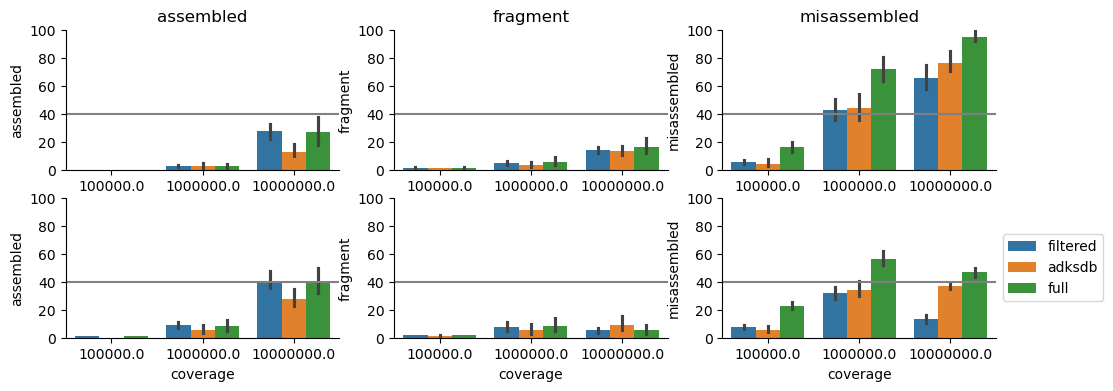

In [345]:
fig = plt.figure(figsize=(12, 4))
for i, col in enumerate(['assembled', 'fragment', 'misassembled']):
    ax = fig.add_subplot(2,3,i+1)
    sns.barplot(data=assembly_info[assembly_info['tool'].eq('plass')], x='coverage', y=col, hue='filtered')
    ax.set_title(col)
    ax.get_legend().remove()
    ax.set_ylim(0, 100)
    ax.axhline(40, color='gray')
    ax = fig.add_subplot(2,3,4+i)
    sns.barplot(data=assembly_info[assembly_info['tool'].eq('spades')], x='coverage', y=col, hue='filtered')
    ax.set_ylim(0, 100)
    ax.axhline(40, color='gray')
    sns.despine()
    if i+4 != 6:
        ax.get_legend().remove()
    else:
        lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

<Axes: xlabel='coverage', ylabel='assembled'>

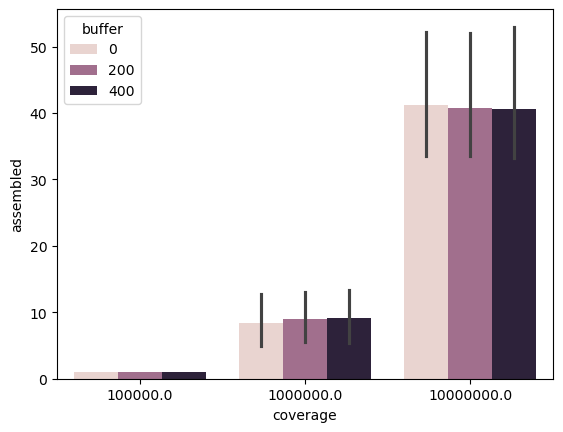

In [355]:
sns.barplot(data=assembly_info[assembly_info['tool'].eq('spades') &
                             assembly_info['filtered'].eq('filtered')], 
            x='coverage', y='assembled', hue='buffer')

<Axes: xlabel='tcov', ylabel='pident'>

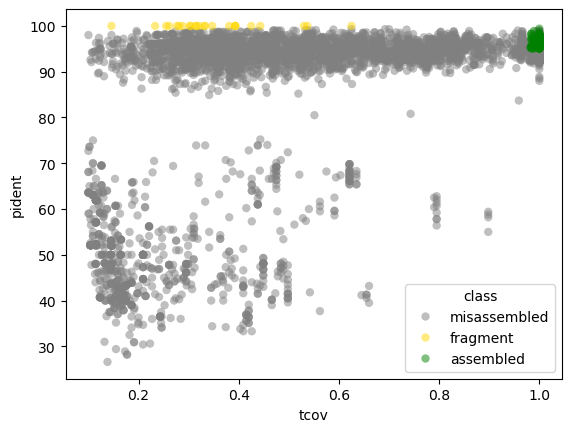

In [280]:
sns.scatterplot(data=plotdf.sort_values('class', ascending=False), 
                x='tcov', y='pident', hue='class',
               palette=['green', 'gold', 'gray'][::-1], linewidth=0, alpha=0.5)

In [272]:
plotdf.groupby('target')

,target,pident,qcov,tcov,qlen,tlen,evalue,class
3752,JBCCAR010000023.1_43,96.2,0.991,0.991,216.0,216.0,0.0,assembled
445,QCOF01000002.1_30,96.2,0.995,1.0,188.0,187.0,0.0,assembled
531,QCOF01000002.1_30,97.2,0.984,0.989,188.0,187.0,0.0,assembled
535,QCOF01000002.1_30,96.2,0.984,0.989,188.0,187.0,0.0,assembled
390,QCOF01000002.1_30,96.2,0.995,1.0,188.0,187.0,0.0,assembled
...,...,...,...,...,...,...,...,...
6716,CAIPFY010000137.1_23,95.5,0.965,0.576,141.0,236.0,0.0,misassembled
7386,DAIMYR010000002.1_287,39.2,0.333,0.168,84.0,167.0,0.000092,misassembled
2712,DAIMYR010000002.1_348,96.2,1.0,0.124,81.0,653.0,0.0,misassembled
1351,JAOHEU010000016.1_9,92.0,0.991,1.0,215.0,213.0,0.0,misassembled


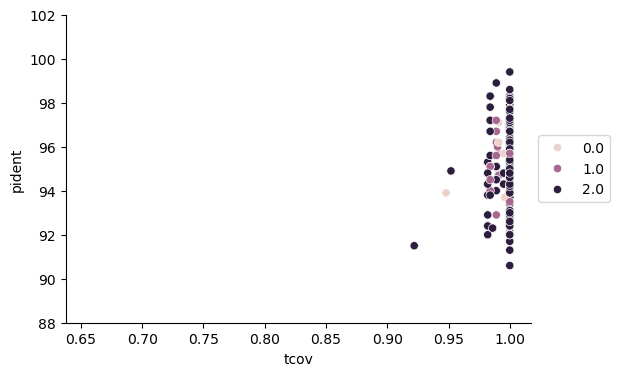

In [258]:
fig, ax = plt.subplots(figsize=(6,4))

sns.scatterplot(data=plotdf, x='tcov', y='pident',
       hue=np.abs(plotdf['qlen'] - plotdf['tlen']))
ax.set_ylim(88, 102)
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
sns.despine()

In [249]:
target_hits[target_hits['target'].isin(actual_seqids) &
            target_hits['pident'].eq(100)] #.sort_values('tcov')

,target,pident,qcov,tcov,qlen,tlen,evalue
3800,JBCCAR010000023.1_43,100.0,1.0,0.315,68.0,216.0,0.0
5270,CACEAR010000003.1_28,100.0,0.988,0.393,85.0,214.0,0.0
8566,CAXBVE010000002.1_96,100.0,1.0,0.314,58.0,185.0,0.0
51,NVTH01000106.1_10,100.0,1.0,0.277,59.0,213.0,0.0
2013,JAUMDJ010000029.1_20,100.0,1.0,0.381,83.0,218.0,0.0
2014,JANQLZ010000144.1_17,100.0,0.983,0.261,59.0,222.0,0.0
8337,CALCBL010000199.1_1,100.0,0.99,0.303,96.0,314.0,0.0
61,NVTH01000134.1_6,100.0,0.984,0.53,62.0,115.0,0.0
42,NVTH01000106.1_10,100.0,0.947,0.333,75.0,213.0,0.0
6711,CAIPFY010000137.1_23,100.0,0.988,0.347,83.0,236.0,0.0


In [248]:
target_hits.sort_values('pident')

,target,pident,qcov,tcov,qlen,tlen,evalue
6062,JAOJEQ010000001.1_58,26.6,0.417,0.138,72.0,218.0,0.000974
6375,CACNSV010000050.1_4,28.2,0.557,0.177,70.0,220.0,0.00011
6374,CACNSV010000050.1_4,28.2,0.557,0.177,70.0,220.0,0.00011
7122,LIBD01000039.1_1,28.5,0.862,0.268,65.0,209.0,0.000732
4396,CACNSV010000050.1_4,28.9,0.76,0.173,50.0,220.0,0.000034
...,...,...,...,...,...,...,...
5270,CACEAR010000003.1_28,100.0,0.988,0.393,85.0,214.0,0.0
42,NVTH01000106.1_10,100.0,0.947,0.333,75.0,213.0,0.0
7757,CAKZZH010000089.1_4,100.0,1.0,0.443,90.0,203.0,0.0
3800,JBCCAR010000023.1_43,100.0,1.0,0.315,68.0,216.0,0.0


In [190]:
assembly_info.loc[100, 'file']

'/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/targeted_assembly/mmseqs_assemblies/aquatic_sims/plass_aquatic_1e7_adksdb_sim0_assembly.faa'

In [139]:
def plot_assembly_success(df, labels=True):
    # Defines thresholds for categorization and plot lines
    IDENTITY_THRESHOLD = 95
    COVERAGE_THRESHOLD = 0.95
    
    # Ensures the necessary categorization column exists for coloring
    if 'Quality_Category' not in df.columns:
        df['Quality_Category'] = 'Fragmented/Poor'
        df.loc[(df['Coverage_Fraction'] >= COVERAGE_THRESHOLD) & (df['Max_Percent_Identity'] >= IDENTITY_THRESHOLD), 'Quality_Category'] = 'High Confidence Assembly'
        df.loc[(df['Coverage_Fraction'] < COVERAGE_THRESHOLD) & (df['Max_Percent_Identity'] >= 90), 'Quality_Category'] = 'High Identity, Low Coverage (Fragmented)'
        df.loc[(df['Max_Percent_Identity'] < 90), 'Quality_Category'] = 'Low Identity (Misassembly/Distant)'

    # sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(4, 2))
    ax = fig.add_subplot(1, 2, 1)
    # Scatter plot using Identity, Coverage, Fragment Count, and Quality Category
    sns.scatterplot(
        data=df,
        x='Coverage_Fraction', 
        y='Max_Percent_Identity', 
        hue='Quality_Category',
        hue_order=['High Confidence Assembly', 'High Identity, Low Coverage (Fragmented)', 'Low Identity (Misassembly/Distant)', 'Fragmented/Poor'],
        size='Fragment_Count', 
        sizes=(20, 300), 
        alpha=0.7, 
        palette=sns.color_palette('viridis_r', n_colors=4)
    )

    ax.set_xlim(0, 1.15)
    ax.set_ylim(45, 115)
    ax.axvline(COVERAGE_THRESHOLD, 
       color='r', 
       linestyle='--', linewidth=1, label=f'Coverage Threshold ({COVERAGE_THRESHOLD*100:.0f}%)')
    ax.axhline(IDENTITY_THRESHOLD, 
       color='b', 
       linestyle='--', linewidth=1, label=f'Identity Threshold ({IDENTITY_THRESHOLD:.0f}%)')

    if labels:
        # Adds visual thresholds
        ax.axvline(COVERAGE_THRESHOLD, 
                   color='r', 
                   linestyle='--', linewidth=1, label=f'Coverage Threshold ({COVERAGE_THRESHOLD*100:.0f}%)')
        ax.axhline(IDENTITY_THRESHOLD, 
                   color='b', 
                   linestyle='--', linewidth=1, label=f'Identity Threshold ({IDENTITY_THRESHOLD:.0f}%)')
        
        # Labels quadrants for interpretation
        ax.text(COVERAGE_THRESHOLD + 0.1, 
                IDENTITY_THRESHOLD + 2, 
                'High Confidence Full Assembly', 
                color='green', 
                fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
        
        ax.text(0.05, 
                IDENTITY_THRESHOLD + 2, 
                'Highly Fragmented', color='orange', 
                fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
        ax.text(0.5, 50, 
                'Low Identity/Misassembled', 
                color='red', 
                fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
    
        # Final plot aesthetics
        ax.set_title('Assembly Success Evaluation: \nCoverage vs. Identity', fontsize=16, pad=20)
        ax.set_xlabel('Coverage Fraction (Fraction of Original Protein Covered)', fontsize=12)
        ax.set_ylabel('Max Percent Identity (%)', fontsize=12)

        ax.legend(title="Assembly Quality (Point Size = Fragment Count)", bbox_to_anchor=(1, 0.5), loc='center left')
    else:
        
        ax.get_legend().remove()

    ax = fig.add_subplot(1,2,2)
    hue_order = ['High Confidence Assembly', 'High Identity, Low Coverage (Fragmented)', 'Low Identity (Misassembly/Distant)', 'Fragmented/Poor']
    sns.barplot(summary['Quality_Category'].value_counts().reindex(hue_order).fillna(0),
                palette=sns.color_palette('viridis_r', n_colors=4))
    sns.despine()
    ax.set_xticks([''])
    sns.despine()
    fig.subplots_adjust(wspace=0.5)
    # plt.tight_layout(rect=[0, 0, 0.85, 1])

In [71]:
def get_summary_df(blast_result):
    # Load the BLASTP results
    df = pd.read_csv(blast_result, sep='\t', header=None,
                     names=['qseqid', 'sseqid', 'pident', 'aln_len', 'mismatch', 'gapopen', 
                            'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore', 
                            'qlen', 'slen'])
    
    # Identify unique original proteins (subjects)
    original_proteins = df['sseqid'].unique()
    
    # Prepare a list to store results for each original protein
    results = []
    
    for protein_id in original_proteins:
        # Get all alignment hits for this original protein
        hits = df[df['sseqid'] == protein_id]
    
        # Get the length of the original protein (Subject Length)
        # Assuming all hits for the same subject have the same slen
        original_length = hits['slen'].iloc[0]
    
        # --- Calculate Coverage ---
    
        # A set to track covered positions on the original protein (1-based index)
        covered_positions = set()
        for index, row in hits.iterrows():
            # Alignment start and end on the subject (original protein)
            # Ensure start <= end regardless of orientation
            start = min(row['sstart'], row['send'])
            end = max(row['sstart'], row['send'])
    
            # Add all positions covered by this fragment to the set
            covered_positions.update(range(start, end + 1))
    
        coverage = len(covered_positions) / original_length
    
        # --- Calculate Max Identity ---
    
        # The quality of the best-matching fragment
        max_identity = hits['pident'].max()
    
        # --- Calculate Max Bitscore ---
        max_bitscore = hits['bitscore'].max()
    
        results.append({
            'Original_Protein_ID': protein_id,
            'Original_Length': original_length,
            'Fragment_Count': len(hits),
            'Coverage_Fraction': coverage,
            'Max_Percent_Identity': max_identity,
            'Max_Bitscore': max_bitscore
        })
    
    return pd.DataFrame(results)

/tmp/ipykernel_2299593/1566176603.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(summary['Quality_Category'].value_counts().reindex(hue_order).fillna(0),


(89, 7)

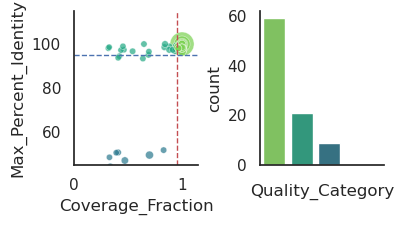

In [141]:
summary = get_summary_df(os.path.abspath('./../data/targeted_assembly/filtered_assemblies/gut_1e7_filtered_b200_assembly_blastp_results.tsv'))
plot_assembly_success(summary, labels=False)
summary.shape

/tmp/ipykernel_2299593/3178137051.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(summary['Quality_Category'].value_counts().reindex(hue_order).fillna(0),


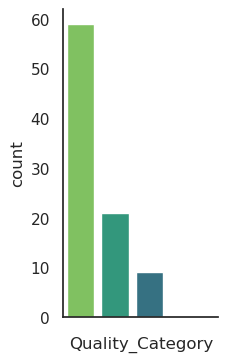

In [132]:
fig, ax = plt.subplots(figsize=(2,4))
hue_order = ['High Confidence Assembly', 'High Identity, Low Coverage (Fragmented)', 'Low Identity (Misassembly/Distant)', 'Fragmented/Poor']
sns.barplot(summary['Quality_Category'].value_counts().reindex(hue_order).fillna(0), 
            palette=sns.color_palette('viridis_r', n_colors=4))
sns.despine()
ax.set_xticks([''])

(87, 7)

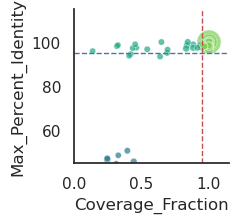

In [122]:
summary =get_summary_df(os.path.abspath('./../data/targeted_assembly/filtered_assemblies/gut_1e7_filtered_b0_assembly_blastp_results.tsv'))
plot_assembly_success(summary, labels=False)
summary.shape

(36, 7)

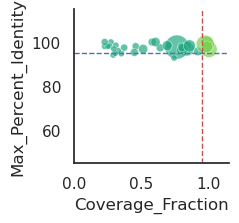

In [124]:
summary = get_summary_df(os.path.abspath('./../data/targeted_assembly/filtered_assemblies/gut_1e6_filtered_b0_assembly_blastp_results.tsv'))
plot_assembly_success(summary, labels=False)
summary.shape

In [116]:
summary

,Original_Protein_ID,Original_Length,Fragment_Count,Coverage_Fraction,Max_Percent_Identity,Max_Bitscore,Quality_Category
0,HF986002.1_4,1141,16,0.834356,97.030,229.0,"High Identity, Low Coverage (Fragmented)"
1,FR893107.1_9,1139,46,0.762072,97.701,330.0,"High Identity, Low Coverage (Fragmented)"
2,FR879706.1_6,208,2,0.697115,97.468,158.0,"High Identity, Low Coverage (Fragmented)"
3,FR895361.1_14,209,1,0.272727,100.000,115.0,"High Identity, Low Coverage (Fragmented)"
4,LCQS01000018.1_12,208,4,0.798077,98.039,205.0,"High Identity, Low Coverage (Fragmented)"
5,PASX01000036.1_10,213,2,0.370892,97.468,157.0,"High Identity, Low Coverage (Fragmented)"
6,DPDV01000007.1_49,226,7,0.991150,98.649,228.0,High Confidence Assembly
7,SFGS01000013.1_18,228,2,0.456140,98.077,205.0,"High Identity, Low Coverage (Fragmented)"
8,SBFN01000203.1_6,174,3,0.637931,97.368,149.0,"High Identity, Low Coverage (Fragmented)"
9,VFKM01000022.1_2,190,20,1.000000,96.667,310.0,High Confidence Assembly


<Axes: xlabel='Coverage_Fraction', ylabel='Max_Percent_Identity'>

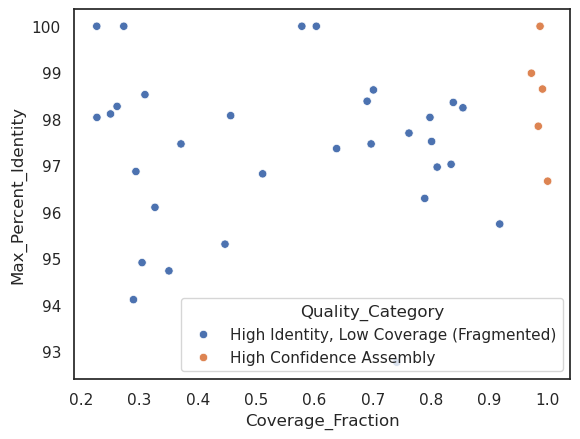

In [117]:
sns.scatterplot(data=summary,
                x='Coverage_Fraction',
                y='Max_Percent_Identity',
               hue='Quality_Category')